# 02 - Exploratory Data Analysis & Visualization
Crop Productivity Prediction Project

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Load cleaned data
data_agri = pd.read_csv('../data/cleaned_agriculture_data.csv')
data_agri.head()

,Crop,Prod2011,Prod2012,Prod2013,Prod2014,Prod2015,Area2011,Area2012,Area2013,Area2014,Area2015,Yield2011,Yield2012,Yield2013,Yield2014,Yield2015,Weather,Season
0,Total Foodgrains,158.8,168.6,171.3,159.40,178.9,128.5,128.8,127.6,126.0,131.7,123.6,130.9,134.3,126.5,135.9,Rainy,Kharif
1,Rice,200.8,207.9,213.3,191.60,206.4,168.5,168.9,175.1,161.2,164.8,119.2,123.1,121.8,118.9,125.2,Overcast,Rabi
2,Wheat,131.6,136.4,140.1,140.30,150.8,115.0,115.2,114.0,116.9,119.5,114.4,118.4,122.8,120.0,126.3,Overcast,Kharif
3,Jowar,124.3,137.8,126.0,116.50,121.8,120.7,110.6,107.3,111.0,105.2,103.0,124.6,117.4,105.0,115.8,Sunny,Rabi
4,Bajra,136.4,161.5,143.9,146.95,167.9,94.5,95.1,87.0,88.5,95.6,144.3,169.7,165.4,119.0,175.8,Rainy,Rabi


In [2]:
# Basic Statistics
data_agri.describe()

,Prod2011,Prod2012,Prod2013,Prod2014,Prod2015,Area2011,Area2012,Area2013,Area2014,Area2015,Yield2011,Yield2012,Yield2013,Yield2014,Yield2015
count,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,145.383333,156.909259,156.192593,152.659259,180.914815,115.927778,118.264815,120.420370,118.133333,127.042593,127.759259,133.516667,130.822222,128.451852,143.344444
std,48.664387,59.594109,64.413850,63.186059,84.224028,38.340719,41.662526,44.870024,45.395890,55.342333,31.539945,30.490548,29.579976,30.647852,33.723390
min,53.900000,54.400000,50.000000,42.900000,42.100000,47.900000,47.400000,43.600000,37.500000,36.100000,86.000000,75.300000,72.700000,80.700000,80.800000
25%,124.400000,119.500000,114.025000,116.975000,124.350000,92.125000,92.550000,92.700000,88.575000,90.625000,106.750000,116.750000,110.725000,108.050000,120.725000
50%,141.650000,158.450000,154.350000,146.950000,168.700000,119.500000,121.550000,121.650000,120.100000,128.950000,118.400000,124.050000,123.200000,121.050000,137.650000
75%,177.900000,197.775000,185.250000,189.775000,212.875000,131.175000,136.800000,136.275000,134.800000,148.575000,134.525000,152.750000,147.725000,140.825000,167.925000
max,253.200000,313.800000,367.100000,329.100000,409.100000,222.700000,241.600000,254.500000,260.300000,314.700000,218.500000,205.200000,200.500000,227.000000,230.900000


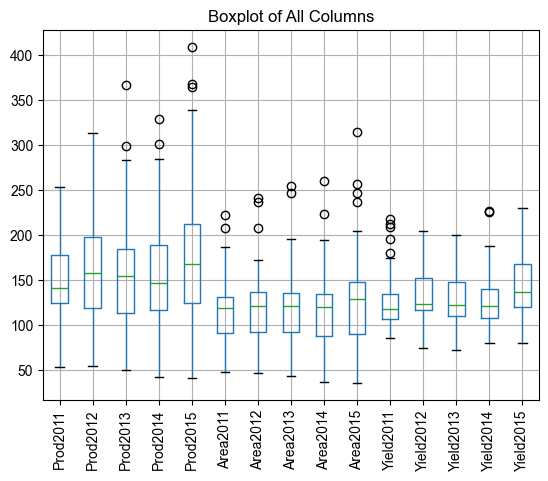

In [3]:
# Boxplot - checking distribution
data_agri.boxplot()
plt.xticks(rotation=90)
sns.set_style('darkgrid')
plt.title("Boxplot of All Columns")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_11216\3416405646.py:3: FutureWarning: The provided callable <function mean at 0x0000028147CFDBD0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  x = grp['Prod2015'].agg(np.mean)
C:\Users\HP\AppData\Local\Temp\ipykernel_11216\3416405646.py:4: FutureWarning: The provided callable <function mean at 0x0000028147CFDBD0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  y = grp['Area2015'].agg(np.mean)
C:\Users\HP\AppData\Local\Temp\ipykernel_11216\3416405646.py:5: FutureWarning: The provided callable <function mean at 0x0000028147CFDBD0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instea

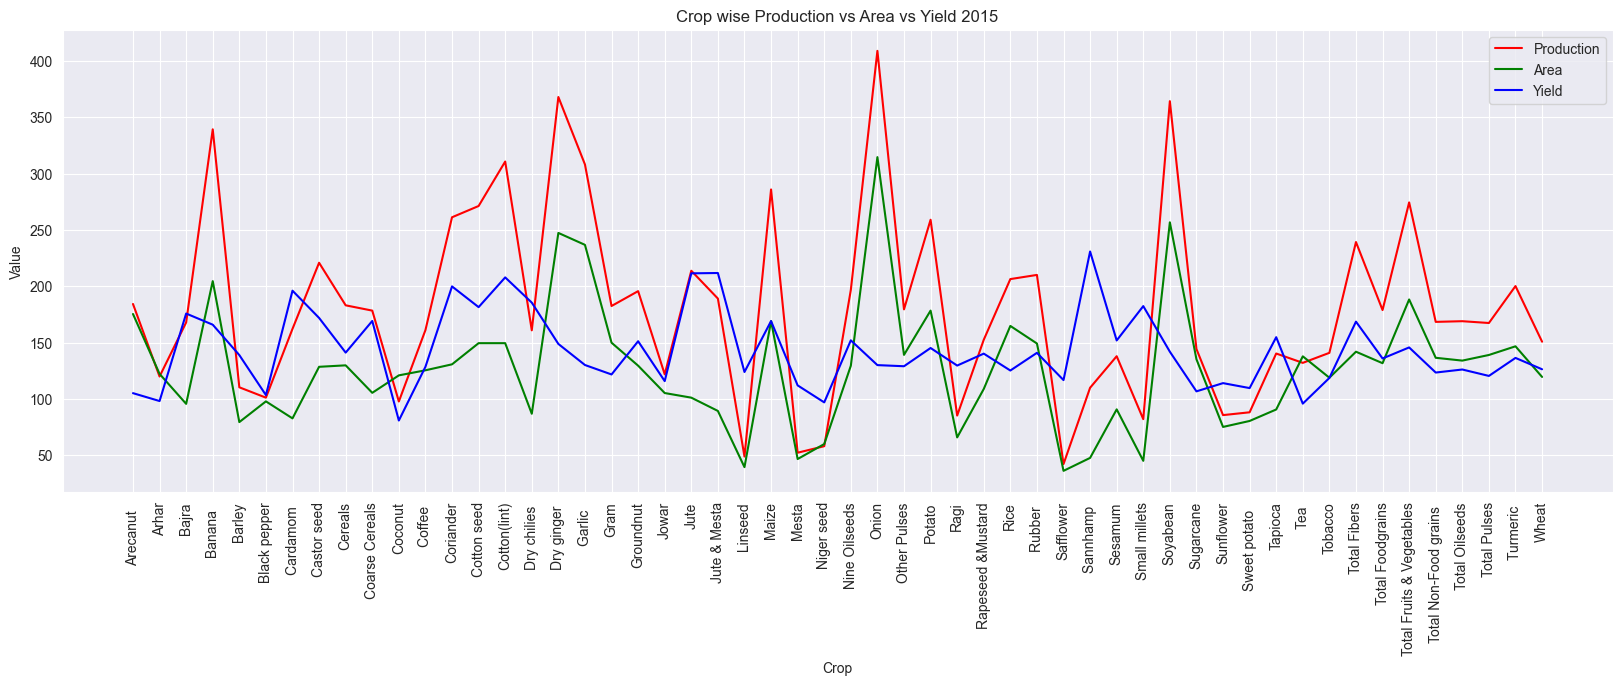

In [4]:
# Production vs Area comparison
grp = data_agri.groupby('Crop')
x = grp['Prod2015'].agg(np.mean)
y = grp['Area2015'].agg(np.mean)
z = grp['Yield2015'].agg(np.mean)

plt.figure(figsize=(20,6))
plt.plot(x, color='r', label='Production')
plt.plot(y, color='g', label='Area')
plt.plot(z, color='b', label='Yield')
plt.title("Crop wise Production vs Area vs Yield 2015")
plt.xticks(rotation=90)
plt.ylabel("Value")
plt.xlabel("Crop")
plt.legend()
plt.show()

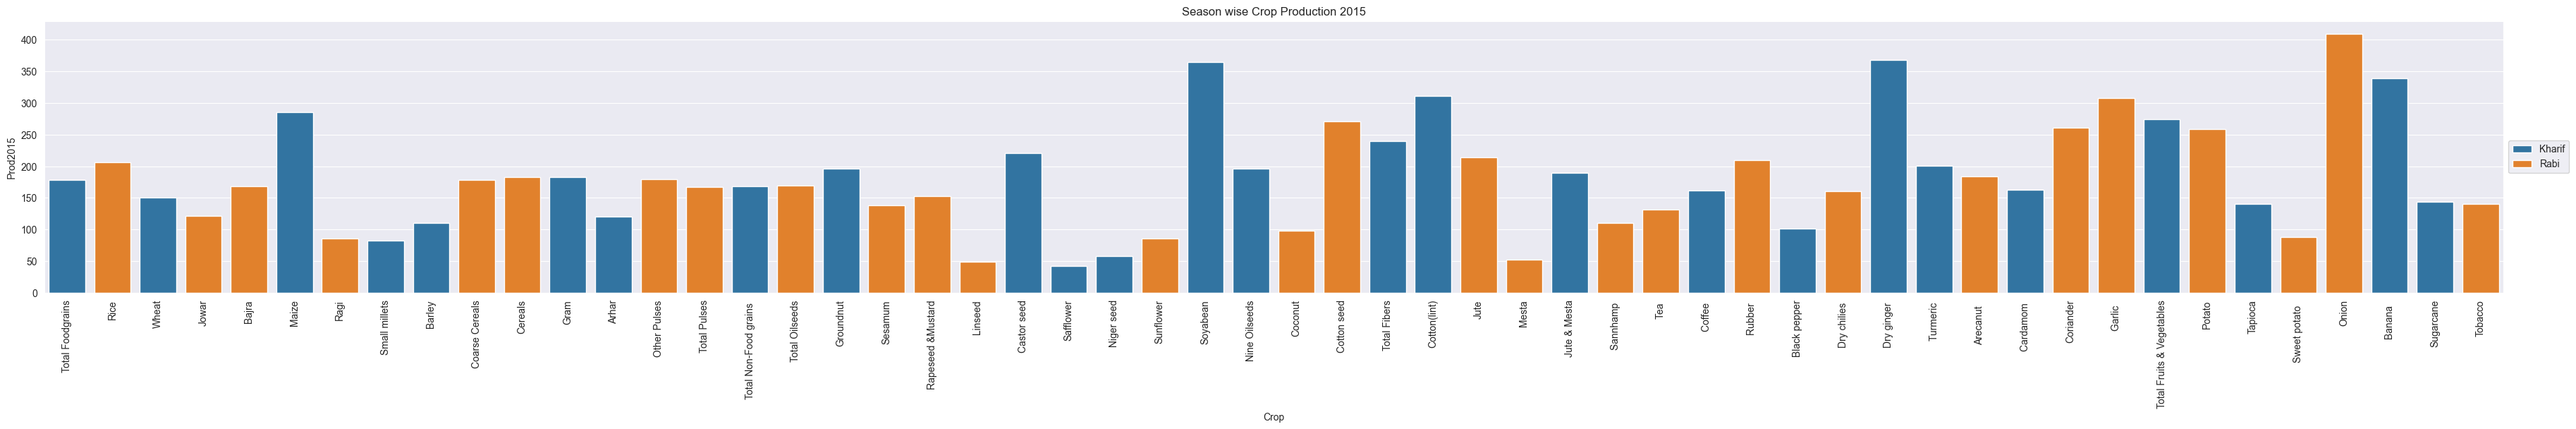

In [5]:
# Season wise production barplot
plt.figure(figsize=(45,5))
sns.barplot(x='Crop', y='Prod2015', data=data_agri, hue='Season')
plt.xticks(rotation=90)
plt.title("Season wise Crop Production 2015")
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show()

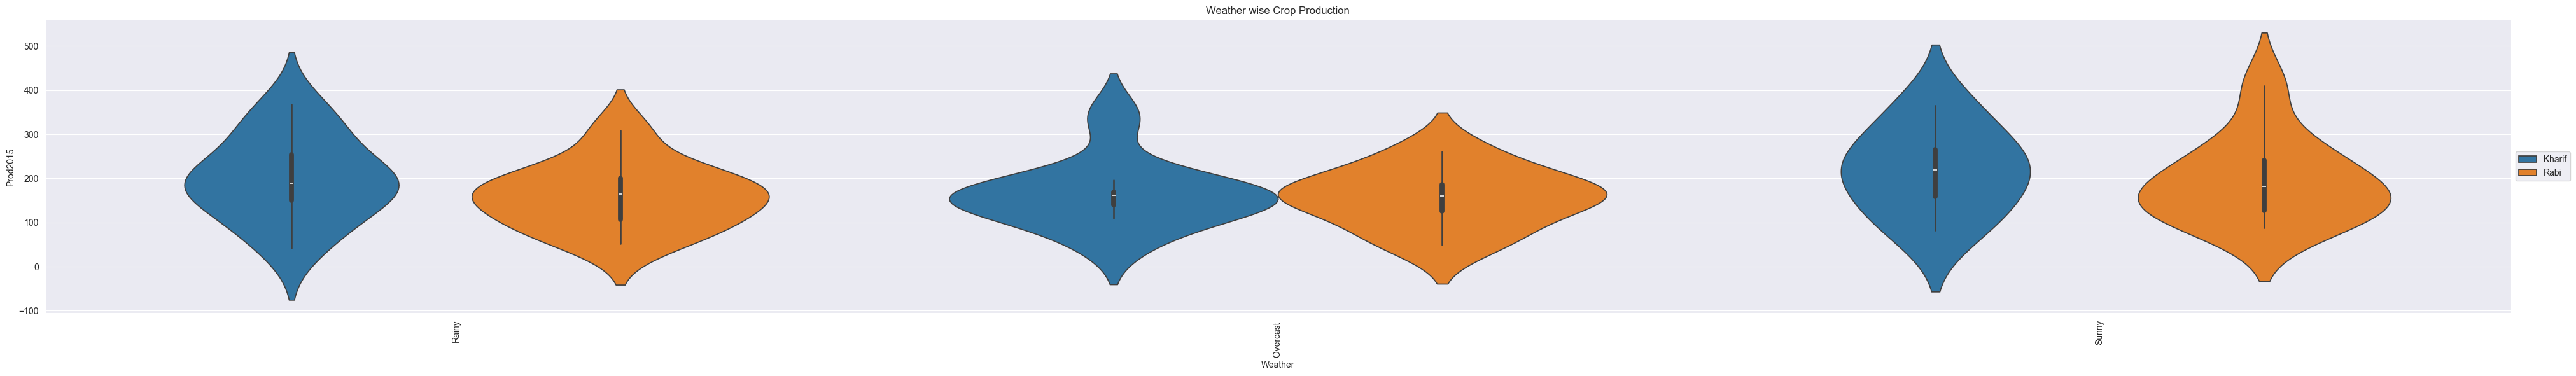

In [6]:
# Weather wise violin plot
plt.figure(figsize=(50,6))
sns.violinplot(x='Weather', y='Prod2015', data=data_agri, hue='Season')
plt.title("Weather wise Crop Production")
plt.xticks(rotation=90)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show()

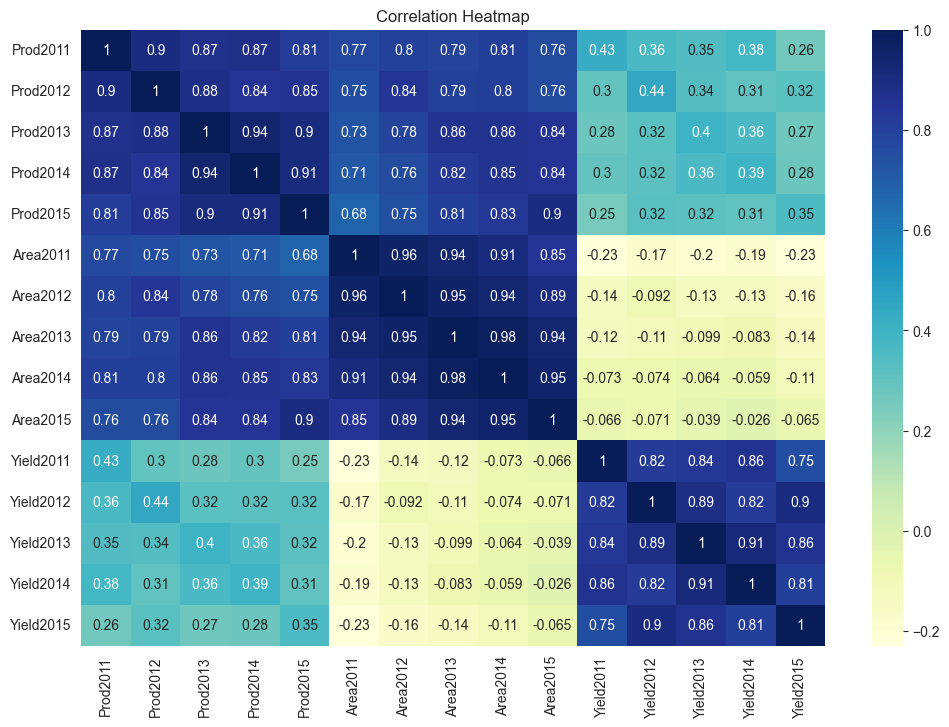

In [7]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(data_agri.select_dtypes(include='number').corr(), annot=True, cmap='YlGnBu')
plt.title("Correlation Heatmap")
plt.show()